# ARIMA Modeling and Forecasting with Residual Diagnostics
This notebook demonstrates ARIMA modeling on NVDA stock data with residual diagnostic checks.

In [7]:
# install yfinance, pmdarima, q for quiet, not show redundant messages
!pip install -q yfinance     
!pip install -q pmdarima

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error

## 1. Data Loading and Preparation

Download NVDA stock data and prepare monthly log returns.

In [9]:
# Download NVDA daily data
ticker = "NVDA"
start_date = "2010-01-01"
end_date = "2025-12-31"

data = yf.download(ticker, start=start_date, end=end_date)
daily_close = data['Close']

print(f"Daily data range: {daily_close.index[0].date()} to {daily_close.index[-1].date()}")
print(f"Daily rows: {len(daily_close)}")

# Resample to monthly (using 'ME' instead of deprecated 'M')
monthly_close = daily_close.resample("ME").last()
print(f"\nMonthly rows: {len(monthly_close)}")

# Calculate log returns
monthly_returns = np.log(monthly_close / monthly_close.shift(1)).dropna()
print(f"Monthly returns rows: {len(monthly_returns)}")

[*********************100%***********************]  1 of 1 completed

Daily data range: 2010-01-04 to 2025-12-30
Daily rows: 4023

Monthly rows: 192
Monthly returns rows: 191


## 2. Descriptive Analysis

- **Line graph of stock return:** Monthly return of the stock over time
- **Lag-1 scatter plot:** if points follows diagonal pattern, suggests autocorrelation
- **Normality check (histogram, Jarque–Bera test)** if histogram is bell-shaped, then appears to be normally distributed.
- **Rolling mean, stationarity visual check:** a roughly stable mean around 0, relatively stable variance over time suggests stationarity.

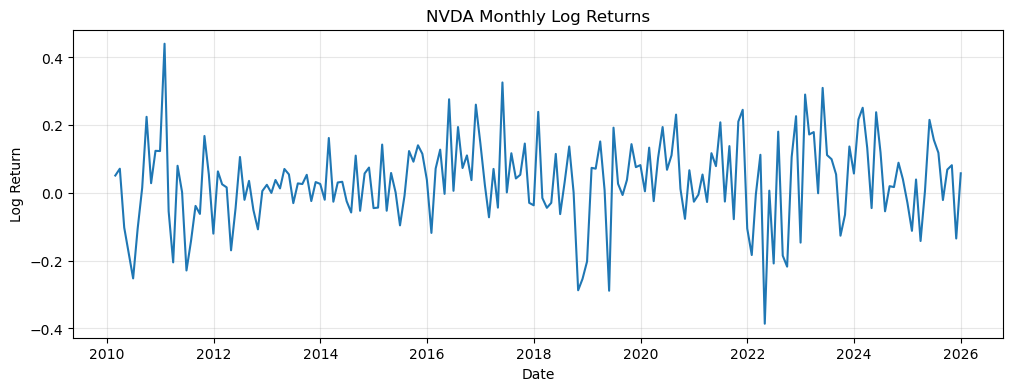

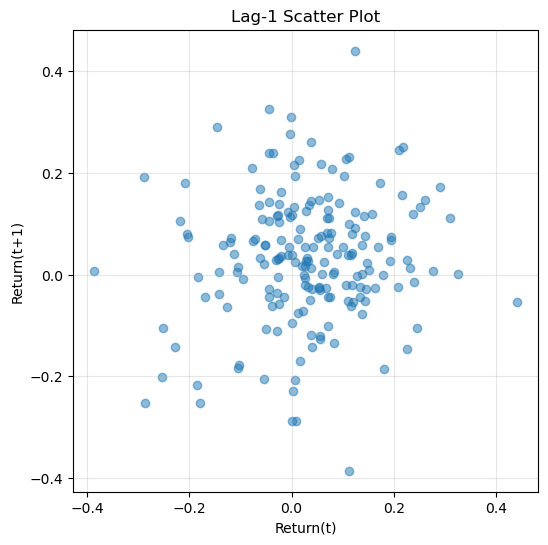

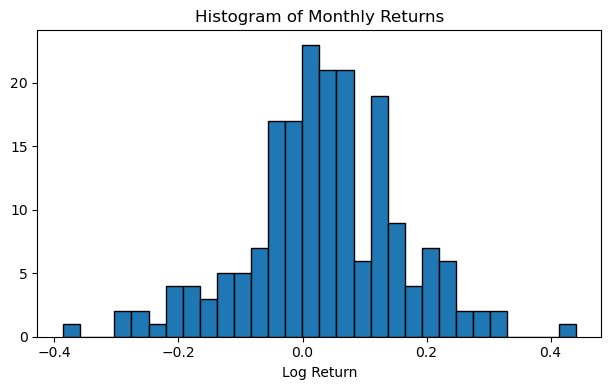


Jarque-Bera Test for Normality:
Statistic: 6.1316
p-value: 0.0466
Conclusion: Returns are not normally distributed (reject normality)


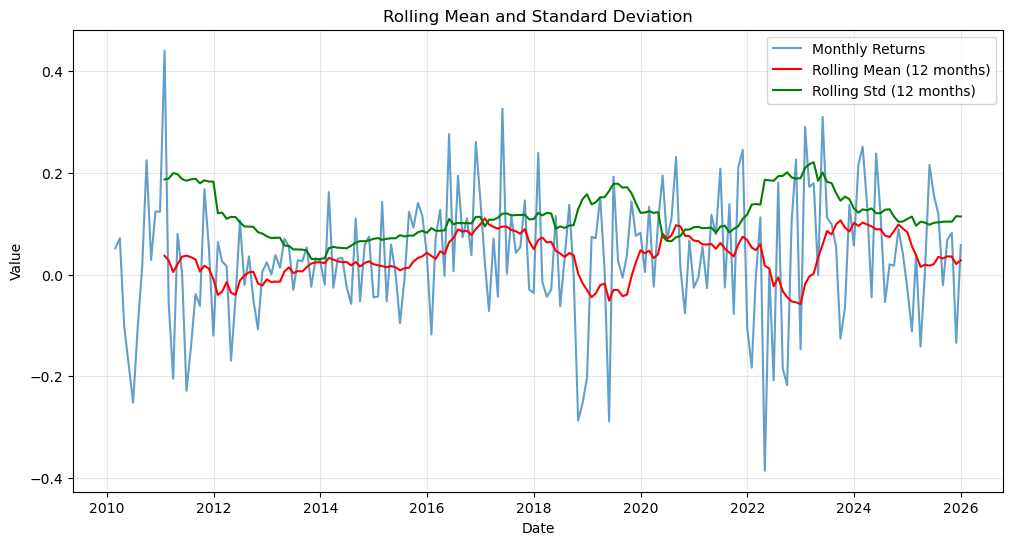

In [10]:
# Time series plot
plt.figure(figsize=(12, 4))
plt.plot(monthly_returns)
plt.title("NVDA Monthly Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)
plt.show()

# Lag-1 scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(monthly_returns[:-1], monthly_returns[1:], alpha=0.5)
plt.xlabel("Return(t)")
plt.ylabel("Return(t+1)")
plt.title("Lag-1 Scatter Plot")
plt.grid(True, alpha=0.3)
plt.show()

# Normality check
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(monthly_returns, bins=30, edgecolor='black')
plt.title("Histogram of Monthly Returns")
plt.xlabel("Log Return")


plt.tight_layout()
plt.show()

# Jarque-Bera test for normality
jb_stat, jb_p = stats.jarque_bera(monthly_returns)[:2]
print(f"\nJarque-Bera Test for Normality:")
print(f"Statistic: {jb_stat:.4f}")
print(f"p-value: {jb_p:.4f}")
if jb_p < 0.05:
    print("Conclusion: Returns are not normally distributed (reject normality)")
else:
    print("Conclusion: Returns appear normally distributed (fail to reject normality)")

# Rolling statistics for stationarity check
rolling_mean = monthly_returns.rolling(window=12).mean()
rolling_std = monthly_returns.rolling(window=12).std()

plt.figure(figsize=(12, 6))
plt.plot(monthly_returns, label='Monthly Returns', alpha=0.7)
plt.plot(rolling_mean, label='Rolling Mean (12 months)', color='red')
plt.plot(rolling_std, label='Rolling Std (12 months)', color='green')
plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Stationarity Test (ADF Test)
For ARIMA (p,d,q),
Test if the series is stationary, to determine the differencing order (d).

In [11]:
# ADF Test
adf_result = adfuller(monthly_returns, autolag='AIC')
adf_stat = adf_result[0]
adf_pval = adf_result[1]

print("ADF Test (Dickey–Fuller) on NVDA monthly log returns")
print(f"ADF statistic: {adf_stat:.6f}")
print(f"p-value      : {adf_pval:.6f}")

if adf_pval < 0.05:
    print("Conclusion   : Stationary (reject unit root)")
    d_order = 0
else:
    print("Conclusion   : Non-stationary (fail to reject unit root)")
    d_order = 1

print(f"Chosen differencing order d = {d_order}")

ADF Test (Dickey–Fuller) on NVDA monthly log returns
ADF statistic: -12.304299
p-value      : 0.000000
Conclusion   : Stationary (reject unit root)
Chosen differencing order d = 0


With d=0, the ARIMA(p,0,q) model is equivalent to ARMA(p,q) model.

## 4. Train-Test Split

Split data into training (80%) and testing (20%) sets.

In [12]:
# Train-test split (80-20)
train_size = int(len(monthly_returns) * 0.8)
train_data = monthly_returns[:train_size]
test_data = monthly_returns[train_size:]

print(f"Training set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")
print(f"\nTrain period: {train_data.index[0].date()} to {train_data.index[-1].date()}")
print(f"Test period: {test_data.index[0].date()} to {test_data.index[-1].date()}")

Training set size: 152
Test set size: 39

Train period: 2010-02-28 to 2022-09-30
Test period: 2022-10-31 to 2025-12-31


## 5. Method 1: Manual ARIMA Order Selection (ACF/PACF Analysis)

Visual inspection to identify potential p and q parameters.

**Interpretation:**
- **ACF** (Autocorrelation Function)
  - If ACF cuts off after lag q, suggests MA(q)
  - If ACF decays gradually, suggests AR component
  
- **PACF** (Partial Autocorrelation Function)
  - If PACF cuts off after lag p, suggests AR(p)
  - If PACF decays gradually, suggests MA component

**Common patterns:**
- AR(p): PACF cuts off at lag p, ACF decays
- MA(q): ACF cuts off at lag q, PACF decays
- ARMA(p,q): Both decay gradually

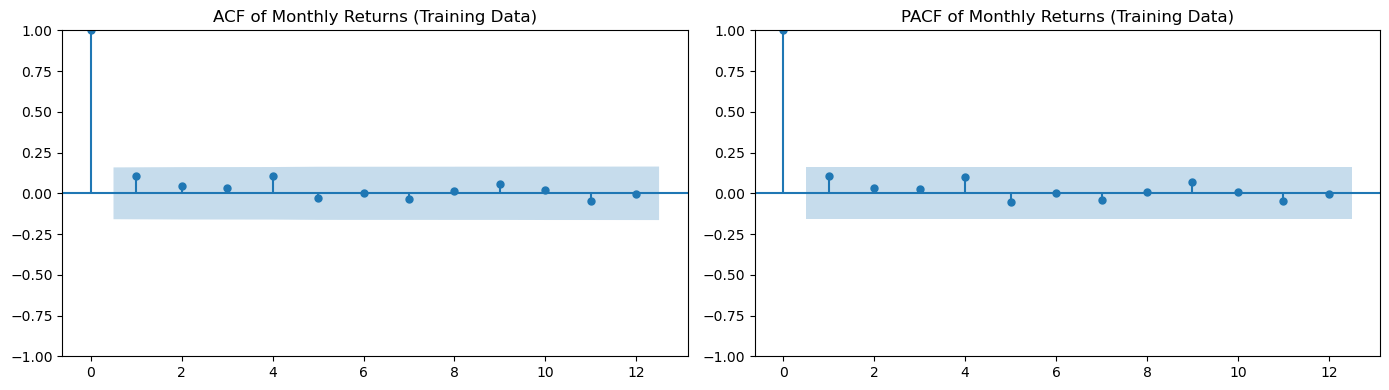

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(train_data, lags=12, ax=axes[0])
axes[0].set_title("ACF of Monthly Returns (Training Data)")

plot_pacf(train_data, lags=12, ax=axes[1])
axes[1].set_title("PACF of Monthly Returns (Training Data)")

plt.tight_layout()
plt.show()

In [27]:
# Based on ACF/PACF visual inspection, manually select p and q
# Adjust these values based on what you see in the plots above

print("="*60)
print("MANUAL ORDER SELECTION")
print("="*60)
manual_p = 1  # based on PACF
manual_q = 1  # based on ACF

manual_order = (manual_p, d_order, manual_q)
print(f"\nManual selection: ARIMA{manual_order}")

# Fit the manually selected model
manual_model = ARIMA(train_data, order=manual_order)
manual_fit = manual_model.fit()

print(f"\nManual Model Results:")
print(f"AIC: {manual_fit.aic:.4f}")
print(f"BIC: {manual_fit.bic:.4f}")
print("="*60)

MANUAL ORDER SELECTION

Manual selection: ARIMA(1, 0, 1)

Manual Model Results:
AIC: -197.8299
BIC: -185.7344


## 6. Method 2: Automated ARIMA Order Selection (auto_arima)

Use auto_arima to systematically search for the best model.

**Parameters:**
- `start_p, start_q`: Starting values for search
- `max_p, max_q`: Maximum values (set to 12 for monthly data, to allow for annual patterns)
- `d`: Fixed differencing order from ADF test
- `seasonal=False`: No seasonal component 
- `information_criterion='aic'`: Uses AIC for model selection

In [28]:
print("="*60)
print("AUTOMATED ARIMA ORDER SELECTION")
print("="*60)
# Auto ARIMA search
auto_model_fit = auto_arima(train_data,
                            start_p=0, max_p=12,
                            start_q=0, max_q=12,
                            d=d_order,
                            seasonal=False,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True,
                            information_criterion='aic',
                            max_order=None)  # No constraint on p+q

auto_order = auto_model_fit.order
auto_aic = auto_model_fit.aic()

print("\n" + "="*60)
print(f"Auto-selected ARIMA order: {auto_order}")
print(f"AIC: {auto_aic:.4f}")
print(f"BIC: {auto_model_fit.bic():.4f}")
print("="*60)

AUTOMATED ARIMA ORDER SELECTION
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-196.259, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-197.147, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-196.792, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-195.818, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-197.990, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-196.162, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-196.166, Time=0.17 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-195.453, Time=0.03 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-194.123, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-197.830, Time=0.16 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 0.778 seconds

Auto-selected ARIMA order: (1, 0, 1)
AIC: -197.9897
BIC: -188.9181


Both manual and automated order selection suggest for ARMA(1,1).

## 7. Final Model Summary

Display the summary of the selected model.

In [17]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                  152
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 102.915
Date:                Mon, 09 Feb 2026   AIC                           -197.830
Time:                        17:19:51   BIC                           -185.734
Sample:                    02-28-2010   HQIC                          -192.916
                         - 09-30-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0223      0.013      1.685      0.092      -0.004       0.048
ar.L1          0.7115      0.369      1.926      0.054      -0.013       1.436
ma.L1         -0.6220      0.408     -1.526      0.1

## 8. Residual Diagnostics (Training Set)

Check if the model residuals satisfy ARIMA assumptions:
- **Normality** of residuals (Histogram visualization, Q-Q plot, Shapiro-Wilk test)
- **No autocorrelation** (Ljung–Box test, ACF of residuals)
- **Homoscedasticity** (check for constant variance of residual over time)
- **White noise behavior** (Check if residuals behave like white noise）


RESIDUAL DIAGNOSTICS


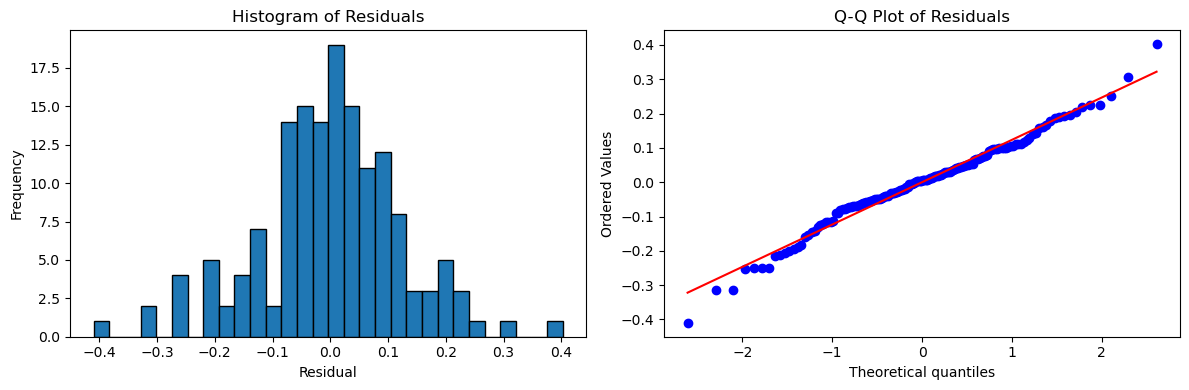


1. NORMALITY TEST
----------------------------------------
Shapiro-Wilk Test: Statistic=0.9842, p-value=0.0805
Residuals appear normally distributed

2. AUTOCORRELATION TEST
----------------------------------------


<Figure size 1000x400 with 0 Axes>

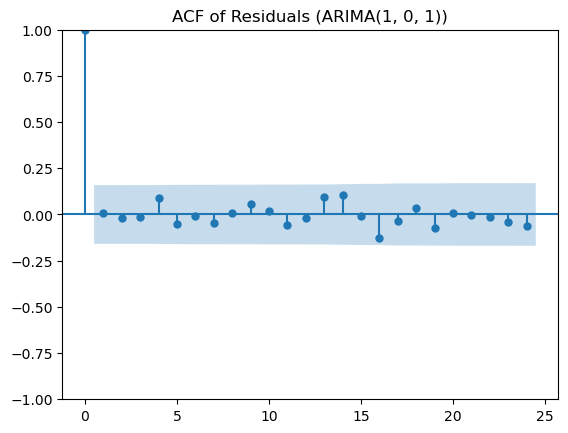

<Figure size 1000x400 with 0 Axes>

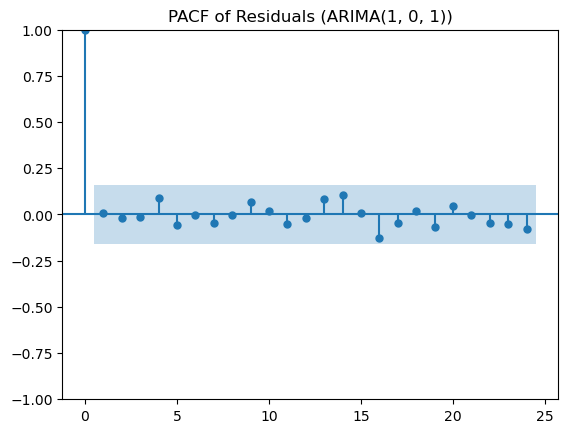


Ljung-Box Test (H0: no autocorrelation):
      lb_stat  lb_pvalue
10   2.796576   0.985814
12   3.413894   0.991849
24  12.133579   0.978361

Interpretation: If p-values > 0.05, residuals show no significant autocorrelation.

3. HOMOSCEDASTICITY CHECK
----------------------------------------


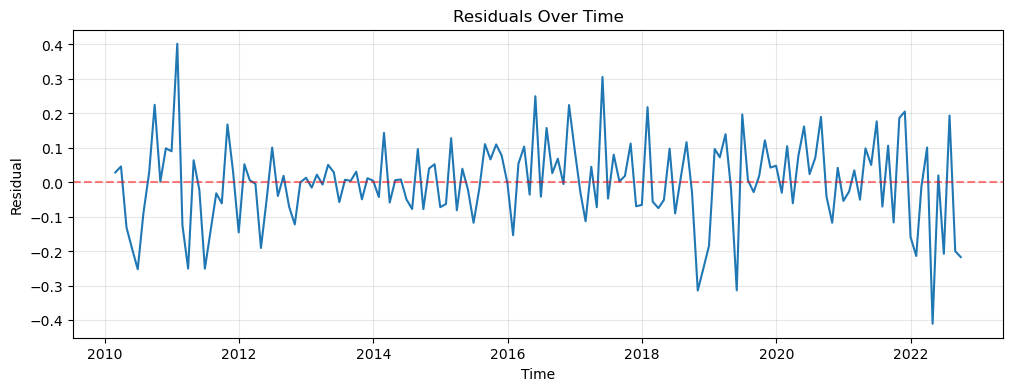

In [33]:
# Extract residuals from the fitted model
residuals = model_fit.resid

# 1. Normality Check
print("="*60)
print("RESIDUAL DIAGNOSTICS")
print("="*60)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

# Shapiro-Wilk Test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\n1. NORMALITY TEST")
print(f"-" * 40)
print(f"Shapiro-Wilk Test: Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("Residuals are NOT normally distributed")
else:
    print("Residuals appear normally distributed")

# 2. Autocorrelation Check
print(f"\n2. AUTOCORRELATION TEST")
print(f"-" * 40)

# ACF plot of residuals
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=24)
plt.title(f"ACF of Residuals (ARIMA{model_order})")
plt.show()

# PACF plot of residuals
plt.figure(figsize=(10, 4))
plot_pacf(residuals, lags=24)
plt.title(f"PACF of Residuals (ARIMA{model_order})")
plt.show()

# Ljung-Box test
lb_test = acorr_ljungbox(residuals, lags=[10, 12, 24], return_df=True)
print("\nLjung-Box Test (H0: no autocorrelation):")
print(lb_test)
print("\nInterpretation: If p-values > 0.05, residuals show no significant autocorrelation.")

# 3. Homoscedasticity Check
print(f"\n3. HOMOSCEDASTICITY CHECK")
print(f"-" * 40)

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.show()



*For the residuals, they follow*：
- **Normal distribution** (from histogram, Q–Q plot, and Shapiro–Wilk test).    
- **Approximately constant variance** (appears to have constant variance from the graph).  
- **No autocorrelation** (from the Ljung–Box test).   
- **White-noise behavior** (generally follow white-noise behavior).  

## 9. Forecasting on Test Set

Time-series forecasting using model identified, then visualize results.

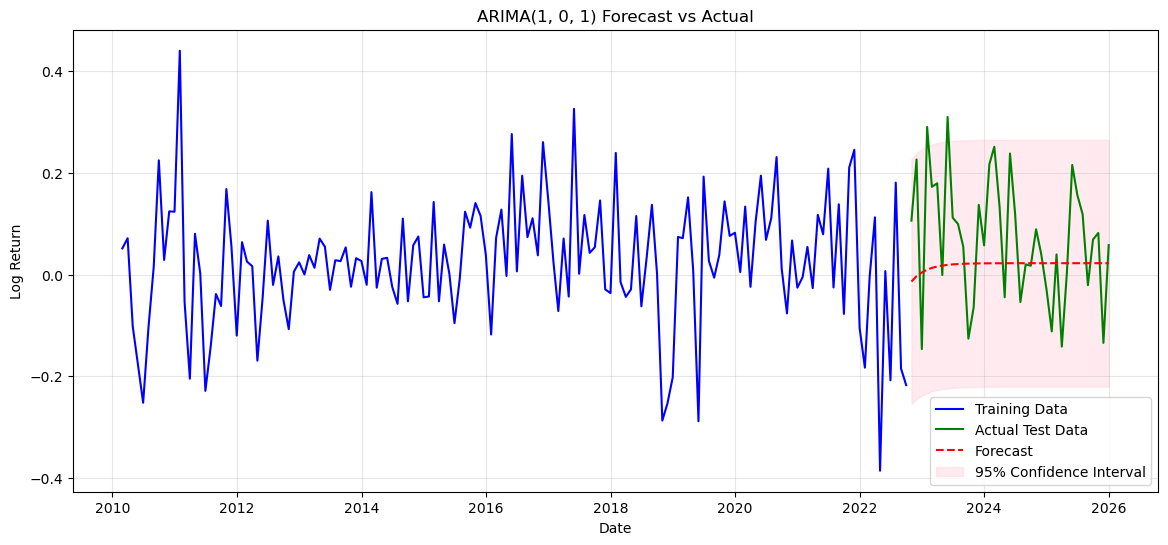

In [19]:
# Forecast on test set
n_forecast = len(test_data)
forecast_result = model_fit.get_forecast(steps=n_forecast)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Align forecast with test data index
forecast_mean.index = test_data.index
forecast_ci.index = test_data.index

# Plot actual vs forecast
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='green')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast_ci.index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title(f"ARIMA{model_order} Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Forecast Evaluation Metrics

Calculate error metrics (MSE, MAE, RMSE)

In [20]:
# Calculate forecast errors
forecast_errors = test_data - forecast_mean

# Error metrics
mse = mean_squared_error(test_data, forecast_mean)
mae = mean_absolute_error(test_data, forecast_mean)
rmse = mse ** 0.5

print("\n" + "="*60)
print("FORECAST ERROR METRICS ON TEST SET")
print("="*60)
print(f"MSE  (Mean Squared Error)     : {mse:.4f}")
print(f"MAE  (Mean Absolute Error)    : {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print("="*60)



FORECAST ERROR METRICS ON TEST SET
MSE  (Mean Squared Error)     : 0.0176
MAE  (Mean Absolute Error)    : 0.1086
RMSE (Root Mean Squared Error): 0.1326


## 11. Summary and Conclusions

Review key findings, provide summary.

In [34]:
print("\n" + "="*60)
print("ARIMA ANALYSIS SUMMARY")
print("="*60)
print(f"\nData: {ticker} Monthly Log Returns")
print(f"Period: {monthly_returns.index[0].date()} to {monthly_returns.index[-1].date()}")
print(f"Total observations: {len(monthly_returns)}")
print(f"\nTrain set: {len(train_data)} observations")
print(f"Test set: {len(test_data)} observations")
print(f"\nModel Selection:")
print(f"  - Manual (ACF/PACF): ARIMA{manual_order}, AIC={manual_fit.aic:.4f}")
print(f"  - Auto ARIMA:        ARIMA{auto_order}, AIC={auto_aic:.4f}")

print(f"\nFinal Model: ARIMA{model_order}")
print(f"AIC: {model_fit.aic:.4f}")
print(f"\nTest Set Performance:")
print(f"  - RMSE: {rmse:.4f}")
print(f"  - MAE:  {mae:.4f}")
print(f"  - Mean Error: {mse:.4f}")
print("\n" + "="*60)


ARIMA ANALYSIS SUMMARY

Data: NVDA Monthly Log Returns
Period: 2010-02-28 to 2025-12-31
Total observations: 191

Train set: 152 observations
Test set: 39 observations

Model Selection:
  - Manual (ACF/PACF): ARIMA(1, 0, 1), AIC=-197.8299
  - Auto ARIMA:        ARIMA(1, 0, 1), AIC=-197.9897

Final Model: ARIMA(1, 0, 1)
AIC: -197.8299

Test Set Performance:
  - RMSE: 0.1326
  - MAE:  0.1086
  - Mean Error: 0.0176

